In [ ]:
# Standard
from collections import namedtuple, deque
import random
from time import sleep

# Third-party
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import trange

# API
from api import KnisterGame

ImportError: cannot import name 'nn' from partially initialized module 'torch' (most likely due to a circular import) (c:\Users\andre\OneDrive - Università di Cagliari\Universita'\Magistrale\Secondo Anno\Reinforcement and Adaptive Learning\Lab\ProgettoRAL\.venv\Lib\site-packages\torch\__init__.py)

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Definizione QNet

In [ ]:
class QNet(nn.Module):
    # Policy Network
    def __init__(self, n_state_vars, n_actions, dim_hidden=128):
        super(QNet, self).__init__()

        # Define a feedforward neural network with hidden layers, ReLU
        #  activations, and an output layer that maps to the number of actions
        self.fc = nn.Sequential(
            # TODO: rivedere architettura rete
            nn.Linear(n_state_vars, dim_hidden),
            nn.ReLU(),
            nn.Linear(dim_hidden, dim_hidden),
            nn.ReLU(),
            nn.Linear(dim_hidden, dim_hidden),
            nn.ReLU(),
            nn.Linear(dim_hidden, n_actions),
        )

    def forward(self, x):
        # Passes the input through the network layers to output Q-values
        return self.fc(x)

## Definizione del Replay Buffer

In [ ]:
class ReplayBuffer:
    def __init__(self, n_actions, memory_size, batch_size):
        # Initialize actions, batch and experience template
        self.n_actions = n_actions
        self.batch_size = batch_size
        self.experience = namedtuple("Experience", field_names=["state", "action", "reward", "next_state", "done"])
        # Initialize the memory
        self.memory = deque(maxlen=memory_size) # Hint: use deque

    def __len__(self):
        return len(self.memory)

    def add(self, state, action, reward, next_state, done):
        # Store experience in memory
        e = self.experience(state, action, reward, next_state, done)
        self.memory.append(e)

    def sample(self):
        # Sample a batch of experiences
        experiences = random.sample(self.memory, self.batch_size)  # Hint: use random

        # Convert to tensors for training
        states = torch.from_numpy(
            np.vstack([e.state for e in experiences if e is not None])
        ).float().to(device)

        actions = torch.from_numpy(
            np.vstack([e.action for e in experiences if e is not None])
        ).long().to(device)

        rewards = torch.from_numpy(
            np.vstack([e.reward for e in experiences if e is not None])
        ).float().to(device)

        next_states = torch.from_numpy(
            np.vstack([e.next_state for e in experiences if e is not None])
        ).float().to(device)

        dones = torch.from_numpy(
            np.vstack([e.done for e in experiences if e is not None]).astype(np.uint8)
        ).float().to(device)

        # Return the tuple with all tensors (we use the brackets to create a tuple)
        return (states, actions, rewards, next_states, dones)

## Definizione della Deep Q-Network

In [ ]:
class DQN:
    def __init__(
        self, n_states, n_actions, batch_size=64, learning_rate=1e-4,
        learn_step=5, gamma=0.99, mem_size=int(1e5), tau=1e-3
    ):
        # Core parameters for learning and updating the Q-network
        self.n_states = n_states
        self.n_actions = n_actions
        self.batch_size = batch_size
        self.gamma = gamma  # Discount factor for future rewards
        self.learn_step = learn_step  # Frequency of learning steps
        self.tau = tau  # Rate for soft updating the target network

        # Initialize the policy network (net_eval) and target network (net_target)
        self.net_eval = QNet(n_states, n_actions).to(device)  # Hint: we have a class for this
        self.net_target = QNet(n_states, n_actions).to(device)  # Hint: we have a class for this
        self.optimizer = optim.Adam(self.net_eval.parameters(), lr=learning_rate)  # Suggestion: use Adam from `optim` with specific learning rate and parameters of the net_eval network
        self.criterion = nn.MSELoss()  # Suggestion: use Mean Squared Error (MSE) as the loss function

        # Initialize memory for experience replay
        self.memory = ReplayBuffer(n_actions, mem_size, batch_size)  # Hint: we have a class for this
        self.counter = 0  # Tracks learning steps for periodic updates

    def getAction(self, state, available_actions, epsilon):
        # Select action using an epsilon-greedy strategy to balance exploration
        #  and exploitation
        state = torch.from_numpy(state).float().unsqueeze(0).to(device)

        self.net_eval.eval()  # Set network to evaluation mode
        with torch.no_grad():
            action_values = self.net_eval(state)
        self.net_eval.train()  # Return to training mode

        # Choose random action with probability epsilon, otherwise choose best
        #  predicted action
        # Generiamo un numero R
        if random.random() < epsilon: # random.random rende un numero tra 0 e 1
            action = random.choice(available_actions) # scelgo casualmente l'azione da fare
        else:
            # Calcolo dei q_values
            q_values = action_values.cpu().data.numpy().squeeze()
            # Creiamo una maschera con -infinito
            mask = np.full(q_values.shape, -1e5)
            # Copiamo solo i valori delle azioni VALIDE nella maschera
            mask[available_actions] = q_values[available_actions]
            # Argmax sulla maschera sceglierà sempre un'azione valida
            action = np.argmax(mask)
        return action

    def save2Memory(self, state, action, reward, next_state, done):
        # Save experience to memory and, if ready, sample from memory and
        #  update the network
        self.memory.add(state, action, reward, next_state, done)
        self.counter += 1  # Increment step counter
        loss = None
        # Perform learning every 'learn_step' steps if enough experiences are
        #  in memory
        if (self.counter % self.learn_step == 0 and len(self.memory) >= self.batch_size):  # Hint: check if counter is a multiple of learn_step and
                  #  memory has enough samples
            experiences = self.memory.sample()  # Hint: retrieve a sample of experiences
            loss = self.learn(experiences)
        return loss

    def learn(self, experiences):
        # Perform a learning step by minimizing the difference between
        #  predicted and target Q-values
        states, actions, rewards, next_states, dones = experiences
        # stampo l'esperienza se il reward è diverso da 0
        
        ## AGGIUNTA DELLA MASCHERA PER LE AZIONI NON VALIDE ##
        q_target_predictions = self.net_target(next_states).detach()
        # recupero le griglie degli stati successivi
        next_states_grids = next_states[:, :25]
        # Creo la maschera per le azioni valide
        invalid_mask = (next_states_grids != 0)
        # Imposto a -inf i Q-values delle azioni non valide
        q_target_predictions[invalid_mask] = -1e5
        #######################################################

        # Compute target Q-values from net_target for stability in training
        q_target = q_target_predictions.max(1)[0].unsqueeze(1)
        #q_target = self.net_target(next_states).detach().max(1)[0].unsqueeze(1)
        y_j = rewards + (self.gamma * q_target * (1 - dones))
            # Bellman equation for target Q-value
        q_eval = self.net_eval(states).gather(1, actions)
            # Q-value predictions from policy network

        # Compute loss and backpropagate to update net_eval
        loss = self.criterion(q_eval, y_j)
        self.optimizer.zero_grad()
        loss.backward()

        """ # AGGIUNTA DELLA CLIP DEL GRADIENTE PER STABILITà
        torch.nn.utils.clip_grad_norm_(self.net_eval.parameters(), 1.0) """

        self.optimizer.step()

        # Update target network with soft update for smooth learning
        self.targetUpdate()

        return loss.item()

    def targetUpdate(self):
        # Soft update to gradually shift target network parameters toward
        #  policy network parameters
        params = zip(self.net_eval.parameters(), self.net_target.parameters())
        for eval_param, target_param in params:
            target_param.data.copy_(
                # tau% dei parametri della rete target vengono aggiornati usando i parametri della rete net_eval
                self.tau * eval_param.data + (1.0 - self.tau) * target_param.data # somma pesata dei parametri
            )

### Funzione per ottenere lo stato normalizzato

In [ ]:
def get_normalized_state(env):
    grid = env.get_grid().flatten()
    dice = env.get_current_roll()
    if dice is None: dice = 0
    # Concateniamo e normalizziamo dividendo per 12.0
    state = np.concatenate((grid, [dice]))
    return state / 12.0

""" # One-hot encoding del dado
def get_normalized_state(env):
    grid = env.get_grid().flatten() / 12.0
    dice = env.get_current_roll()
    if dice is None: dice = 0
    dice_one_hot = np.zeros(13)
    dice_one_hot[dice] = 1.0
    
    # Ora lo stato è un vettore normalizzato di 25 elementi per la griglia e 13 per i possibili valori del dado
    state = np.concatenate((grid, dice_one_hot))
    return state """

### Funzione che controlla se in una riga/colonna/diagonale è possibile fare una scala

In [ ]:
def is_straight_possible_in_line(line):
    # Filtra gli zeri (celle vuote)
    values = [v for v in line if v != 0]
    
    # Se è vuota o ha 1 numero, è sempre possibile fare una scala
    if len(values) <= 1:
        return True
        
    # Se ci sono duplicati non è possibile fare una scala
    if len(values) != len(set(values)):
        return False
        
    # Il range coperto dai numeri inseriti deve essere colmabile in 5 caselle
    if (max(values) - min(values)) >= 5:
        return False
        
    return True

def check_if_straight_is_possible(env, action):
    grid = env.get_grid()
    row, col = divmod(action, env.SIZE)

    lines_to_check = []
    # Aggiungo la riga e la colonna da controllare
    lines_to_check.append(grid[row, :])
    lines_to_check.append(grid[:, col])

    # Se voglio inserire un numero nella diagonale principale la aggiungo alla lista delle righe da controllare
    if action in [0, 6, 12, 18, 24]:
        lines_to_check.append(np.diag(grid))
    # Stessa cosa per la diagonale secondaria
    if action in [4, 8, 12, 16, 20]:
        lines_to_check.append(np.diag(np.fliplr(grid)))

    potential_straight = [is_straight_possible_in_line(line) for line in lines_to_check]
    return potential_straight


### Funzione che restituisce la lunghezza di una scala in una riga/colonna/diagonale e funzione che calcola un bonus in base a eventuali scale incrementate dalla mossa fatta

In [ ]:
def longest_straight(values):
    """Lunghezza massima di una sequenza consecutiva in 'values' (0 = vuoto ignorato)."""
    nums = sorted(set(int(v) for v in values if v > 0))
    if len(nums) < 2:
        return 0
    if max(nums) - min(nums) < 5:
        return len(nums)
    else:
        return 0

def action_bonus(env, action, before_grid, weight=0.25, bonus_full_house=1.0, bonus_straight_with_seven=1.0, full_bonus=2.0):
    """
    Calcola bonus basato sul delta di longest_straight nelle linee toccate dalla mossa.
    - weight: bonus per ogni unità di delta (es. 0.25)
    - full_bonus: bonus aggiuntivo se la mossa completa una scala di lunghezza SIZE (es. 5)
    """
    size = env.SIZE
    row, col = divmod(action, size)
    bonus = 0.0
    lines = [
        (before_grid[row, :], env.get_grid()[row, :]),
        (before_grid[:, col], env.get_grid()[:, col])
    ]
    if action in [0, 6, 12, 18, 24]:
        lines.append((np.diag(before_grid), np.diag(env.get_grid())))
    if action in [4, 8, 12, 16, 20]:
        lines.append((np.diag(np.fliplr(before_grid)), np.diag(np.fliplr(env.get_grid()))))

    for b, a in lines:
        before_len = longest_straight(b)
        after_len = longest_straight(a)
        delta = after_len - before_len
        # ho completato la scala
        if after_len == size and before_len < size:
            if 7 in a:
                bonus += bonus_straight_with_seven
            else: 
                bonus += full_bonus
        else:
            # ho mantenuto una scala
            bonus += weight * delta
        
        # calcolo un bonus se la linea contiene un full house
        _, counts = np.unique(a, return_counts=True)
        counts_sorted = sorted(counts, reverse=True)
        if counts_sorted == [3, 2]:
            bonus += bonus_full_house

    return bonus

## Funzione per il train della rete

In [ ]:
CHECKPOINT_NAME = 'checkpoints/checkpoint.pth'
RECENT_EPISODES = 100  # Number of episodes for average score in early stopping
MIN_EPISODES_FOR_STOP = 100  # Ensures enough episodes before evaluating target

def train(
        env, agent, n_episodes, max_steps,
        eps_start, eps_end, eps_decay,
        target_score, do_store_checkpoint
):
    # Initialize score history and epsilon (exploration rate)
    score_hist = []
    reward_hist = []
    loss_hist = []
    epsilon = eps_start
    
    # Progress bar format for tracking training progress
    bar_format = '{l_bar}{bar:10}| {n:4}/{total_fmt}'\
                 ' [{elapsed:>7}<{remaining:>7}, {rate_fmt}{postfix}]'
    pbar = trange(n_episodes, unit="ep", bar_format=bar_format, ascii=True)

    for idx_epi in pbar:
        # Reset the environment for a new episode
        env.new_game()
        # stato iniziale: griglia e valore dado
        state = get_normalized_state(env)
        episode_reward = 0.0
        episode_losses = []

        for idx_step in range(max_steps):
            # Select an action based on the current policy (epsilon-greedy)
            action = agent.getAction(state, env.get_available_actions(), epsilon)  # Hint: we have something ready for this

            grid_before = env.get_grid()
            env.choose_action(action)
            # Calcolo del bonus per eventuali scale mantenute o completate
            bonus = action_bonus(env, action, grid_before, 
                                 weight=0.25, bonus_full_house=1.0, bonus_straight_with_seven=1.0, full_bonus=2.0)
            reward = env.get_last_reward() + bonus
            episode_reward += reward
            
            done = env.has_finished()
            next_state = get_normalized_state(env)

            # Store experience in memory and update the agent
            step_loss = agent.save2Memory(state, action, reward, next_state, done)  # Hint: what data do we store as "experience"? How we do it?
            state = next_state  # Move to the next state

            if step_loss is not None:
                episode_losses.append(step_loss)
            if done:
                break
        
        # Track scores and decay epsilon for less exploration over time
        score_hist.append(env.get_total_reward())
        reward_hist.append(episode_reward)
        if len(episode_losses) > 0:
            avg_loss = np.mean(episode_losses)
        else:
            avg_loss = 0 # Nessun learning avvenuto in questo episodio
        loss_hist.append(avg_loss) # Salviamo nello storico generale
        score_avg = np.mean(score_hist[-RECENT_EPISODES:])
        reward_avg = np.mean(reward_hist[-RECENT_EPISODES:])
        epsilon = max(epsilon - eps_decay, eps_end)  # Hint: epsilon decreases, but we have a minimum

        # Update the progress bar with the current score and average
        pbar.set_postfix_str(
            f"Score: {env.get_total_reward(): 3.2f}, {RECENT_EPISODES} score avg: {score_avg: 3.2f}, Reward: {episode_reward: 3.2f}, {RECENT_EPISODES} reward avg: {reward_avg: 3.2f}"
        )
        pbar.update(0)

        # Early stopping condition if target score is achieved
        if len(score_hist) >= 100 and score_avg >= target_score:
            print("\nTarget Reached!")
            break
        
    # Save the trained model if specified
    if do_store_checkpoint:
        torch.save(agent.net_eval.state_dict(), CHECKPOINT_NAME)
    # Print completion message based on early stopping or max episodes
    if (idx_epi + 1) < n_episodes:
        print("\nTraining complete - target reached!")
    else:
        print("\nTraining complete - maximum episodes reached.")

    return score_hist, reward_hist, loss_hist

## Funzione per il test della rete

In [ ]:
def print_grid(grid: np.ndarray):
    """Print the current grid state to the console."""
    print("    1   2   3   4   5")
    print("  +---+---+---+---+---+")
    for r in range(5):
        row_vals = []
        for c in range(5):
            val = grid[r, c]
            row_vals.append(f"{val:2d}" if val != 0 else "  ")
        print(f"{r + 1} |" + " |".join(row_vals) + " |")
        print("  +---+---+---+---+---+")
    print()

In [ ]:
def testKnister(env, agent, num_tests, max_steps):
    # Run the agent in the environment for the specified number of test episodes
    total_rewards = []
    bar_format = '{l_bar}{bar:10}| {n:4}/{total_fmt}'\
                 ' [{elapsed:>7}<{remaining:>7}, {rate_fmt}{postfix}]'
    pbar = trange(num_tests, unit="ep", bar_format=bar_format, ascii=True)
    best_reward = -float('inf')
    best_grid = None
    for idx_epi in pbar:
        env.new_game()
        state = get_normalized_state(env)
        episode_reward = 0

        for idx_step in range(max_steps):
            # Select action without exploration for deterministic behavior
            action = agent.getAction(state, env.get_available_actions(), epsilon=0)  # Hint: be careful choosing epsilon (in questo modo visto che siamo in test scegliamo l'azione migliore)
            env.choose_action(action)
            # Perform the action and observe the next state and reward
            reward = env.get_last_reward()
            done = env.has_finished()
            state = get_normalized_state(env)
            episode_reward += reward

            # End episode if the agent reaches a terminal state
            if done:
                break
        
        if episode_reward > best_reward:
            best_reward = episode_reward
            best_grid = env.get_grid()
        total_rewards.append(episode_reward)
        pbar.set_postfix_str(
            f"Score: {episode_reward: 7.2f}, 100 score avg: {np.mean(total_rewards[-100:]): 7.2f}"
        )
        
    print(f"\nTest complete! Average Test Reward: {np.mean(total_rewards): .2f}")
    print(f"\nGrid of BEST test episode with score {best_reward}:")
    print_grid(best_grid)

In [ ]:
def plotHist(values, filename, title="Score History", ylabel="Score"):
    # Plot the agent's score history to visualize learning progress
    plt.figure()
    plt.plot(values)
    plt.title(title)
    plt.xlabel("Episodes")
    plt.ylabel(ylabel)
    plt.savefig(filename)
    plt.show()
    plt.close()

## Definizione Parametri

In [ ]:
BATCH_SIZE = 64            # Number of experiences sampled per learning step (32, 64, 128)
LR = 1e-4                  # Learning rate for optimizer (1e-3, 1e-4)
EPISODES = 300000          # Maximum number of episodes to train (~1 or 2 minute for 100 episodes)
TARGET_SCORE = 70          # Early stop if average score reaches this value (punteggio che dovrebbe fare la navetta quando atterra)
GAMMA = 0.99               # Discount factor for future rewards
MEMORY_SIZE = 1000000      # Maximum capacity of replay memory (multiplo di mille)
LEARN_STEP = 10            # Frequency (in steps) of learning updates (5, 10)
TAU = 1e-3                 # Soft update rate for the target network (1e-3)
SAVE_CHKPT = True          # Option to save trained model checkpoint

# Exploration parameters
MAX_STEPS = 30             # Maximum steps per episode
EPS_START = 1.0            # Initial epsilon for exploration (100% exploration at start)
EPS_END = 0.01             # Minimum epsilon (final exploration rate)
EPS_DECAY = 0.99999        # Epsilon decay rate (controls exploration reduction)

## Train della rete

100%|##########| 300000/300000 [3:47:45<  00:00, 21.95ep/s, Score:  51.00, 100 score avg:  41.62, Reward:  65.00, 100 reward avg:  51.28] 



Training complete - maximum episodes reached.


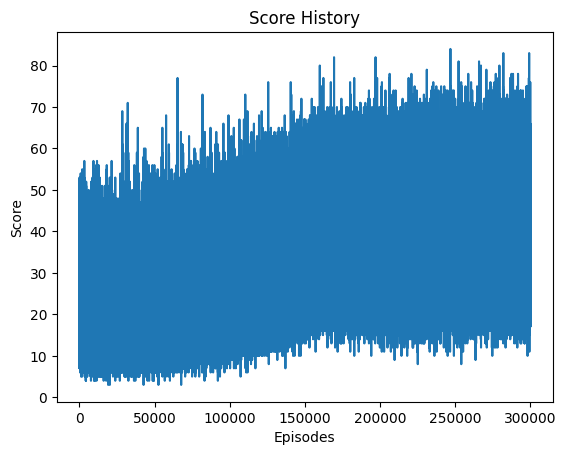

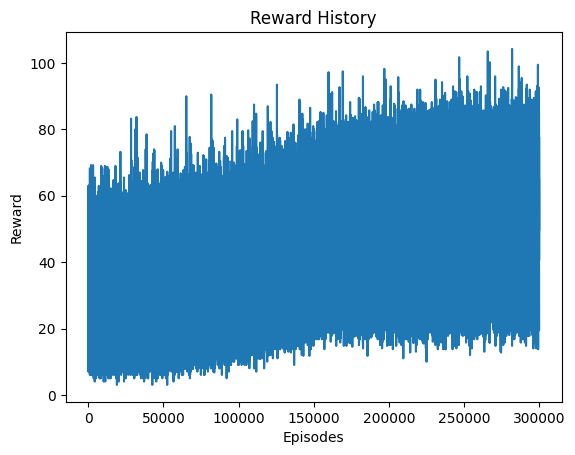

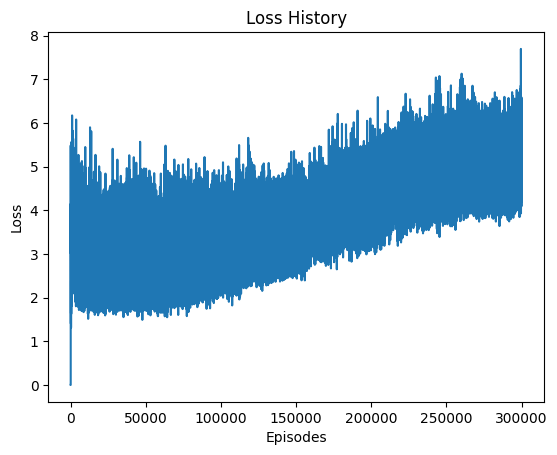

In [ ]:
# Initialize the Knister environment
env = KnisterGame()

# Determine the number of states and actions in the environment
num_states = 26 # numero di caselle della griglia più 1 per il valore del dado
num_actions = 25

# Initialize the DQN agent with customizable parameters
agent = DQN(
    n_states = num_states,
    n_actions = num_actions,
    batch_size = BATCH_SIZE,
    learning_rate = LR,
    gamma = GAMMA,
    mem_size = MEMORY_SIZE,
    learn_step = LEARN_STEP,
    tau = TAU,
)

# Train the agent using the train function and record the score history
score_hist, reward_hist, loss_hist = train(
    env, agent, n_episodes=EPISODES, max_steps=MAX_STEPS,
    eps_start=EPS_START, eps_end=EPS_END, eps_decay=EPS_DECAY,
    target_score=TARGET_SCORE, do_store_checkpoint=SAVE_CHKPT
)

# Plot the score history to visualize training progress over episodes
plotHist(score_hist, "plots/score_history.png", title="Score History", ylabel="Score")
plotHist(reward_hist, "plots/reward_history.png", title="Reward History", ylabel="Reward")
plotHist(loss_hist, "plots/loss_history.png", title="Loss History", ylabel="Loss")

# Free up GPU memory if using CUDA
if str(device) == "cuda":
    torch.cuda.empty_cache()

## Test della rete su 500 match

In [ ]:
NUM_TEST_EPISODES = 500  # Number of episodes to test the agent
MAX_STEPS_TEST = 30    # Maximum steps per test episode

# Run the trained agent for a series of test episodes
if SAVE_CHKPT:
    agent = DQN(
        n_states = num_states,
        n_actions = num_actions,
        batch_size = BATCH_SIZE,
        learning_rate = LR,
        gamma = GAMMA,
        mem_size = MEMORY_SIZE,
        learn_step = LEARN_STEP,
        tau = TAU,
        model = CHECKPOINT_NAME,
    )
testKnister(env, agent, num_tests=NUM_TEST_EPISODES, max_steps=MAX_STEPS_TEST)

100%|##########|  500/500 [  00:07<  00:00, 62.62ep/s, Score:   42.00, 100 score avg:   42.84]


Test complete! Average Test Reward:  43.24

Grid of BEST test episode with score 69:
    1   2   3   4   5
  +---+---+---+---+---+
1 | 7 | 4 | 7 | 5 | 7 |
  +---+---+---+---+---+
2 | 2 | 7 | 7 | 7 | 9 |
  +---+---+---+---+---+
3 | 8 | 4 | 7 | 7 |11 |
  +---+---+---+---+---+
4 |10 | 6 | 7 | 7 |10 |
  +---+---+---+---+---+
5 | 6 | 4 | 7 | 5 | 7 |
  +---+---+---+---+---+

